<a href="https://colab.research.google.com/github/swapnasaina274/malicious-mobile-app-detection/blob/main/02_Deep_Learning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if "Adware" in f or f.endswith(".tar.gz"):
            path = os.path.join(root, f)
            print(path)

/content/drive/MyDrive/Dataset/Adware.tar


In [5]:
import tarfile

apk_archive = "/content/drive/MyDrive/Dataset/Adware.tar"

with tarfile.open(apk_archive, "r:") as tar:
    members = tar.getmembers()

print("Total archive entries:", len(members))

apk_files = [
    m for m in members
    if m.name.lower().endswith(".apk")
]

print("Number of APKs:", len(apk_files))

print("\nFirst 20 APKs:")
for m in apk_files[:20]:
    print(m.name)

Total archive entries: 1516
Number of APKs: 0

First 20 APKs:


In [6]:
total_size = sum(m.size for m in apk_files)

print(f"Total APK size after extraction: {total_size / (1024**3):.2f} GB")

Total APK size after extraction: 0.00 GB


In [7]:
import tarfile

apk_archive = "/content/drive/MyDrive/Dataset/Adware.tar"

with tarfile.open(apk_archive, "r:") as tar:
    members = tar.getmembers()

print("First 50 archive entries:")
for m in members[:50]:
    print(m.name)

First 50 archive entries:
Adware/53dc2935ee199d8d7efa38f66823beb4c278167060bb1083c336049c946b726f.2defc17b7aaf02ade46725cdb434278d
Adware/cd854fa1a0dcac165447042dd152b1bbac2004d519dc3cf31bedadcc5482a4a2.9d237b926b548665a51ec8a25f7bfa00
Adware/c247b7cc81f68873e0fc58a1bbb2a80c5b8265653cdffe47e6b8f3f4ac274d18.4b42ec449ce1a884dbc24936b81b884f
Adware/86fde6f59ef9a8f762af7bb62dfc4467ca9bd3acc63e50e5ab78a7b4487ed70d.4c56f23df7068391d0dba18f5d3f73c7
Adware/eeeea1573010c81ea0851e2c86a2af429676b9129208cd1efd192cb12191789e.52e3f2dad6ada9ee52ba240832e1e77a
Adware/2a5a644e4f41759d3b664415107924648260423933f51b70e1bec4061115741a.4b4d66f51912ebd864b8d38f111ee42d
Adware/1479457b077f7623c713cbef4805e22ad1d30db2caaf2d340072828f988ca5f0.acee02e49ecc78c8e6ee2d6f130e8b7d
Adware/57d5f79200f1c0f07401a8ca61a2cec66f3c6587c00b37b00e2bf221134b7d3b.d9af8c11d107143370ac42cfaf28771b
Adware/e8baf08a37289e35ba376755710b79cbea57564afa333eaa4cb9330fd6a275c6.80f74860acd8b35343f29d8b51023d0b
Adware/1a2b969ba56b3d3473fe45

In [8]:
print("\nFile extensions found:")

from collections import Counter
import os

extensions = Counter()

for m in members:
    if m.isfile():
        ext = os.path.splitext(m.name)[1].lower()
        extensions[ext] += 1

print(extensions)


File extensions found:
Counter({'.2defc17b7aaf02ade46725cdb434278d': 1, '.9d237b926b548665a51ec8a25f7bfa00': 1, '.4b42ec449ce1a884dbc24936b81b884f': 1, '.4c56f23df7068391d0dba18f5d3f73c7': 1, '.52e3f2dad6ada9ee52ba240832e1e77a': 1, '.4b4d66f51912ebd864b8d38f111ee42d': 1, '.acee02e49ecc78c8e6ee2d6f130e8b7d': 1, '.d9af8c11d107143370ac42cfaf28771b': 1, '.80f74860acd8b35343f29d8b51023d0b': 1, '.b7413b18ac9e71f04ffe5712cc787ee4': 1, '.8a5e9061888e2e859c513d4761a8b72c': 1, '.d56aa5f300743a31e993c74b522c8f2b': 1, '.10c04452e835160369adea96dee2d789': 1, '.8df9f5e769ab60cb7570858474b10542': 1, '.0cfd7a0792ca7ff4d584335c8b8b6ad0': 1, '.3a582df40b4dba1b80457b874bd74ac1': 1, '.a8c4d4f4915c437074d97da6174dbec5': 1, '.017c8738a84bbf1d64c11d70f8294f37': 1, '.8d45cdff6653cd1a5c819ebf887f7856': 1, '.ada7d6413e6f153cae56a9b8cefdcdd7': 1, '.a11853b0d1a19e9e256539a5505c9548': 1, '.a73b3d338eb2dedb78adf2f8b0758bce': 1, '.7a507a36d7bf6e0e6b79743535d56149': 1, '.4c5ec0de924cdab4b10d2e3c05356d95': 1, '.37a7a

In [9]:
import tarfile

apk_archive = "/content/drive/MyDrive/Dataset/Adware.tar"

with tarfile.open(apk_archive, "r:") as tar:
    files = [m for m in tar.getmembers() if m.isfile()]

print("Number of files:", len(files))

# Read only the first few bytes of 5 files directly from the TAR
for m in files[:5]:
    f = tar.extractfile(m)
    header = f.read(8)
    print(m.name)
    print("Size:", round(m.size / (1024**2), 2), "MB")
    print("First 8 bytes:", header)
    print()

Number of files: 1515


OSError: TarFile is closed

In [10]:
import tarfile

apk_archive = "/content/drive/MyDrive/Dataset/Adware.tar"

with tarfile.open(apk_archive, "r:") as tar:
    files = [m for m in tar.getmembers() if m.isfile()]

    print("Number of files:", len(files))
    print("\nChecking first 5 files:\n")

    for m in files[:5]:
        f = tar.extractfile(m)
        header = f.read(8)

        print("File:", m.name)
        print("Size:", round(m.size / (1024**2), 2), "MB")
        print("First 8 bytes:", header)
        print("-" * 80)

Number of files: 1515

Checking first 5 files:

File: Adware/53dc2935ee199d8d7efa38f66823beb4c278167060bb1083c336049c946b726f.2defc17b7aaf02ade46725cdb434278d
Size: 0.34 MB
First 8 bytes: b'PK\x03\x04\x14\x00\x08\x00'
--------------------------------------------------------------------------------
File: Adware/cd854fa1a0dcac165447042dd152b1bbac2004d519dc3cf31bedadcc5482a4a2.9d237b926b548665a51ec8a25f7bfa00
Size: 0.58 MB
First 8 bytes: b'PK\x03\x04\n\x00\x00\x00'
--------------------------------------------------------------------------------
File: Adware/c247b7cc81f68873e0fc58a1bbb2a80c5b8265653cdffe47e6b8f3f4ac274d18.4b42ec449ce1a884dbc24936b81b884f
Size: 1.79 MB
First 8 bytes: b'PK\x03\x04\x14\x00\x08\x00'
--------------------------------------------------------------------------------
File: Adware/86fde6f59ef9a8f762af7bb62dfc4467ca9bd3acc63e50e5ab78a7b4487ed70d.4c56f23df7068391d0dba18f5d3f73c7
Size: 1.52 MB
First 8 bytes: b'PK\x03\x04\n\x00\x00\x00'
---------------------------------

In [11]:
import tarfile

apk_archive = "/content/drive/MyDrive/Dataset/Adware.tar"

apk_like = []
other_files = []

with tarfile.open(apk_archive, "r:") as tar:
    files = [m for m in tar.getmembers() if m.isfile()]

    for m in files:
        f = tar.extractfile(m)
        header = f.read(4)

        if header == b"PK\x03\x04":
            apk_like.append(m)
        else:
            other_files.append((m.name, header))

print("Total files:", len(files))
print("APK-like files:", len(apk_like))
print("Other files:", len(other_files))

if other_files:
    print("\nNon-APK files:")
    for name, header in other_files[:20]:
        print(name, "->", header)

Total files: 1515
APK-like files: 1514
Other files: 1

Non-APK files:
Adware/d0bd743ae8b6da2d76db10930be10e641be47407aab2f6f711af775c6ff97bf0.sh -> b'for '


In [12]:
import os
import tarfile
import numpy as np
from PIL import Image

# ============================================================
# Configuration
# ============================================================

apk_archive = "/content/drive/MyDrive/Dataset/Adware.tar"

output_dir = "/content/drive/MyDrive/Dataset/byteplots/Adware"
os.makedirs(output_dir, exist_ok=True)

MAX_APKS = 200

# ============================================================
# Byte -> image dimension
# ============================================================

def calculate_image_size(n_bytes):
    """
    Choose a near-square image size large enough to contain
    all bytes.
    """
    width = int(np.ceil(np.sqrt(n_bytes)))
    height = int(np.ceil(n_bytes / width))
    return width, height


# ============================================================
# Convert APK bytes -> grayscale byte-plot
# ============================================================

def bytes_to_byteplot(data):
    """
    Convert raw APK bytes into a grayscale image.

    Each byte (0-255) becomes one grayscale pixel.
    """
    data = np.frombuffer(data, dtype=np.uint8)

    width, height = calculate_image_size(len(data))

    # Pad remaining pixels with zero
    padded_size = width * height

    if len(data) < padded_size:
        data = np.pad(
            data,
            (0, padded_size - len(data)),
            mode="constant",
            constant_values=0
        )

    image_array = data.reshape((height, width))

    return Image.fromarray(image_array, mode="L")


# ============================================================
# Process APKs directly from TAR
# ============================================================

count = 0

with tarfile.open(apk_archive, "r:") as tar:

    files = [
        m for m in tar.getmembers()
        if m.isfile() and m.name.lower().endswith(".sh") == False
    ]

    # Safety: only use files that actually look like ZIP/APK files
    apk_files = []

    for m in files:
        f = tar.extractfile(m)

        if f is None:
            continue

        header = f.read(4)

        if header == b"PK\x03\x04":
            apk_files.append(m)

        if len(apk_files) >= MAX_APKS:
            break

    print("APK files selected:", len(apk_files))

    # --------------------------------------------------------
    # Generate byte plots
    # --------------------------------------------------------

    for idx, m in enumerate(apk_files):

        f = tar.extractfile(m)

        if f is None:
            continue

        raw_bytes = f.read()

        image = bytes_to_byteplot(raw_bytes)

        output_path = os.path.join(
            output_dir,
            f"adware_{idx:04d}.png"
        )

        image.save(output_path)

        count += 1

        if (count + 1) % 25 == 0:
            print(f"Generated {count} byte-plots...")


print("\n====================================")
print("Byte-plot generation completed")
print("====================================")
print("Generated:", count)
print("Output:", output_dir)

APK files selected: 200


/tmp/ipykernel_4239/3449836512.py:58: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(image_array, mode="L")


Generated 24 byte-plots...
Generated 49 byte-plots...
Generated 74 byte-plots...
Generated 99 byte-plots...
Generated 124 byte-plots...
Generated 149 byte-plots...
Generated 174 byte-plots...
Generated 199 byte-plots...

Byte-plot generation completed
Generated: 200
Output: /content/drive/MyDrive/Dataset/byteplots/Adware


Total byte-plots: 200


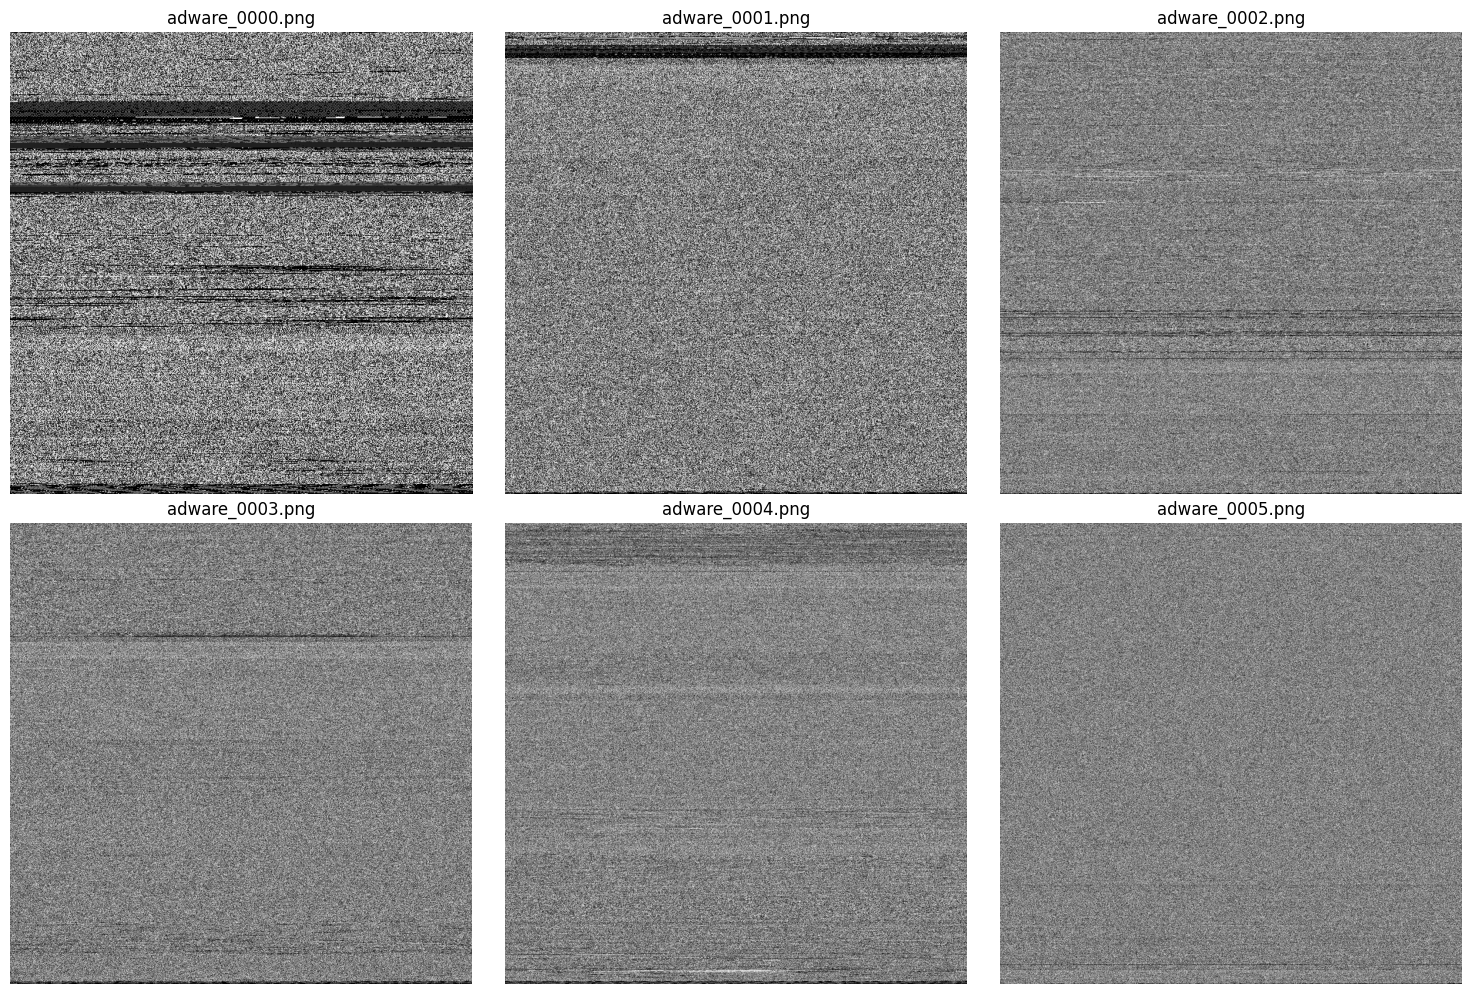

In [13]:
import os
import matplotlib.pyplot as plt
from PIL import Image

output_dir = "/content/drive/MyDrive/Dataset/byteplots/Adware"

files = sorted([
    f for f in os.listdir(output_dir)
    if f.endswith(".png")
])

print("Total byte-plots:", len(files))

# Show 6 examples
plt.figure(figsize=(15, 10))

for i, filename in enumerate(files[:6]):
    image = Image.open(os.path.join(output_dir, filename))

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import requests

url = "http://cicresearch.ca/CICDataset/MalDroid-2020/Dataset/APKs/"

r = requests.get(url, timeout=30)

print("Status:", r.status_code)
print("Content length:", len(r.content))
print(r.text[:1000])

Status: 200
Content length: 108784
<!DOCTYPE html>
<html xmlns="http://www.w3.org/1999/xhtml" lang="en">
<head>
    <script>(function(w,d,s,l,i){w[l]=w[l]||[];w[l].push({'gtm.start':
new Date().getTime(),event:'gtm.js'});var f=d.getElementsByTagName(s)[0],
j=d.createElement(s),dl=l!='dataLayer'?'&amp;l='+l:'';j.async=true;j.src=
'https://www.googletagmanager.com/gtm.js?id='+i+dl;f.parentNode.insertBefore(j,f);
})(window,document,'script','dataLayer','GTM-NML9V78');</script>

<noscript><iframe height="0" src="https://www.googletagmanager.com/ns.html?id=GTM-NML9V78" style="display:none;visibility:hidden" width="0"></iframe></noscript>

<meta content="Datasets; Cybersecurity; Malware" name="keywords"/>
<meta content="Cybersecurity datasets compiled by CIC, ISCX and partners. Used globally for security testing and malware prevention by universities, industry and researchers." name="description"/>
<title>Datasets | Research | Canadian Institute for Cybersecurity | UNB</title>
<meta charset=

In [15]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

url = "http://cicresearch.ca/CICDataset/MalDroid-2020/Dataset/APKs/"

r = requests.get(url, timeout=60)
soup = BeautifulSoup(r.text, "html.parser")

links = []

for a in soup.find_all("a", href=True):
    href = a["href"]
    full_url = urljoin(url, href)
    links.append(full_url)

print("Found", len(links), "links:\n")

for link in links:
    print(link)

Found 130 links:

http://cicresearch.ca/CICDataset/MalDroid-2020/Dataset/APKs/#mcontent
http://cicresearch.ca/CICDataset/MalDroid-2020/Dataset/APKs/#navigation
http://cicresearch.ca/CICDataset/MalDroid-2020/Dataset/APKs/#audnav
https://phonebook.unb.ca
http://www.unb.ca/
http://www.unb.ca/donations/
https://apply.unb.ca/
https://www.unb.ca
http://www.unb.ca/cic/
http://www.unb.ca/alumni
http://www.unb.ca/cic/
http://www.unb.ca/canadian-institute-for-cybersecurity/
http://www.unb.ca/cic/about/index.html
http://www.unb.ca/cic/about/hub.html
http://www.unb.ca/cic/research/index.html
http://www.unb.ca/cic/research/applications.html
http://www.unb.ca/cic/datasets/android-validation.html
http://www.unb.ca/cic/research/pst-conference.html
http://www.unb.ca/cic/research/publications.html
http://www.unb.ca/cic/membership/index.html
http://www.unb.ca/cic/membership/researchers.html
http://www.unb.ca/cic/membership/job-opportunities.html
http://www.unb.ca/cic/datasets/index.html
http://www.unb.ca

In [18]:
import os

path = "/content/drive/MyDrive/Dataset/byteplots/banking"

print("Folder exists:", os.path.exists(path))
print("Number of images:", len(os.listdir(path)))
print(os.listdir(path)[:5])

Folder exists: True
Number of images: 200
['banking_0190.png', 'banking_0183.png', 'banking_0186.png', 'banking_0185.png', 'banking_0177.png']
